# Basketball Team Performance Analysis - Regression
Identify Performance Drivers to Estimate Win Percentage and Rankings


In [1]:
import pandas as pd  
import numpy as np   
import matplotlib.pyplot as plt  
import seaborn as sns  
from scipy import stats  

import warnings
warnings.filterwarnings('ignore')


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
file_path = '11_Baseketball_Team_Performance_Analysis.csv'
df = pd.read_csv(file_path)

In [3]:
df.shape

(10000, 37)

In [4]:
df.columns

Index(['id', 'year', 'rank', 'school', 'games', 'wins', 'losses',
       'win_percentage', 'conference_wins', 'conference_losses', 'home_wins',
       'home_losses', 'away_wins', 'away_losses', 'offensive_rating',
       'defensive_rating', 'net_rating', 'field_goals', 'field_goal_attempts',
       'field_goal_percentage', '3_pointers', '3_pointer_attempts',
       '3_pointer_percentage', 'effective_field_goal_percentage',
       'free_throws', 'free_throw_attempts', 'free_throw_percentage',
       'offensive_rebounds', 'total_rebounds', 'assists', 'steals', 'blocks',
       'turnovers', 'personal_fouls', 'points', 'opponent_points',
       'simple_rating'],
      dtype='object')

In [5]:
df.head()

,id,year,rank,school,games,wins,losses,win_percentage,conference_wins,conference_losses,...,offensive_rebounds,total_rebounds,assists,steals,blocks,turnovers,personal_fouls,points,opponent_points,simple_rating
0,1,2021,1,Villanova,38,30,8,0.789,16,4,...,10.3,34.8,11.9,6.0,2.2,9.9,14.9,71.7,62.7,19.31
1,2,2021,2,Providence,33,27,6,0.818,14,3,...,10.5,37.6,13.2,5.0,3.7,11.4,16.0,71.5,66.2,13.08
2,3,2021,3,UConn,33,23,10,0.697,13,6,...,13.8,40.4,14.0,5.9,6.4,11.8,16.8,74.8,65.3,16.40
3,4,2021,4,Creighton,35,23,12,0.657,12,7,...,9.6,38.1,13.3,5.5,4.3,14.1,13.6,69.2,66.4,11.34
4,5,2021,5,Marquette,32,19,13,0.594,11,8,...,7.8,34.8,16.0,7.8,5.2,12.4,17.4,74.0,71.6,11.36


In [6]:
df.dtypes

id                                   int64
year                                 int64
rank                                 int64
school                              object
games                                int64
wins                                 int64
losses                               int64
win_percentage                     float64
conference_wins                      int64
conference_losses                    int64
home_wins                          float64
home_losses                        float64
away_wins                          float64
away_losses                        float64
offensive_rating                   float64
defensive_rating                   float64
net_rating                         float64
field_goals                        float64
field_goal_attempts                float64
field_goal_percentage              float64
3_pointers                         float64
3_pointer_attempts                 float64
3_pointer_percentage               float64
effective_f

In [7]:
df.isnull().sum()

id                                   0
year                                 0
rank                                 0
school                               0
games                                0
wins                                 0
losses                               0
win_percentage                       0
conference_wins                      0
conference_losses                    0
home_wins                          208
home_losses                        208
away_wins                          208
away_losses                        208
offensive_rating                   278
defensive_rating                   278
net_rating                         278
field_goals                          0
field_goal_attempts                  0
field_goal_percentage                0
3_pointers                          58
3_pointer_attempts                  58
3_pointer_percentage                58
effective_field_goal_percentage     58
free_throws                          0
free_throw_attempts      

In [8]:
df.describe()

,id,year,rank,games,wins,losses,win_percentage,conference_wins,conference_losses,home_wins,...,offensive_rebounds,total_rebounds,assists,steals,blocks,turnovers,personal_fouls,points,opponent_points,simple_rating
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9792.000000,...,9841.000000,10000.000000,9993.000000,9984.000000,9981.000000,9980.000000,9981.000000,10000.000000,10000.000000,10000.000000
mean,248.412600,2000.018200,8.37160,31.367000,20.434800,13.602200,0.600213,8.545300,9.935300,11.064645,...,12.322711,36.379410,14.799860,8.009976,4.842250,14.270301,19.048081,72.791880,68.621000,11.144945
std,144.141145,12.403034,4.63839,6.107474,9.063916,6.801175,0.187888,5.143986,5.387246,4.956641,...,2.713103,4.126262,2.900883,2.153099,2.031402,2.869481,3.159739,6.641915,6.022472,5.893731
min,1.000000,1979.000000,1.00000,19.000000,5.000000,2.000000,0.194000,0.000000,1.000000,2.000000,...,7.500000,27.700000,8.800000,4.000000,1.400000,8.700000,12.700000,58.800000,53.500000,0.000000
25%,123.000000,1989.000000,4.00000,27.000000,13.000000,8.000000,0.464000,4.000000,5.000000,7.000000,...,10.100000,33.100000,12.500000,6.200000,3.200000,11.800000,16.500000,67.900000,64.300000,6.910000
50%,248.000000,2000.000000,8.00000,32.000000,20.000000,14.000000,0.618000,9.000000,10.000000,11.000000,...,12.200000,36.300000,14.700000,8.000000,4.700000,14.200000,18.900000,72.700000,68.500000,11.350000
75%,374.000000,2011.000000,12.00000,36.000000,28.000000,19.000000,0.750000,13.000000,15.000000,15.000000,...,14.400000,39.500000,17.000000,9.700000,6.300000,16.500000,21.400000,77.900000,73.200000,15.480000
max,496.000000,2021.000000,16.00000,41.000000,36.000000,25.000000,0.944000,17.000000,19.000000,19.000000,...,18.600000,45.500000,20.800000,13.100000,9.100000,20.900000,28.400000,89.700000,83.000000,26.640000


## Data Cleaning and Preprocessing

In [9]:
print(df.duplicated().sum())

0


In [29]:
df.isnull().sum()

id                                   0
year                                 0
rank                                 0
school                               0
games                                0
wins                                 0
losses                               0
win_percentage                       0
conference_wins                      0
conference_losses                    0
home_wins                          208
home_losses                        208
away_wins                          208
away_losses                        208
offensive_rating                   278
defensive_rating                   278
net_rating                         278
field_goals                          0
field_goal_attempts                  0
field_goal_percentage                0
3_pointers                          58
3_pointer_attempts                  58
3_pointer_percentage                58
effective_field_goal_percentage     58
free_throws                          0
free_throw_attempts      

In [30]:
critical_cols = ['win_percentage', 'wins', 'losses', 'points', 'opponent_points']
df_clean = df.dropna(subset=critical_cols)

df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

df_clean.isnull().sum()

id                                 0
year                               0
rank                               0
school                             0
games                              0
wins                               0
losses                             0
win_percentage                     0
conference_wins                    0
conference_losses                  0
home_wins                          0
home_losses                        0
away_wins                          0
away_losses                        0
offensive_rating                   0
defensive_rating                   0
net_rating                         0
field_goals                        0
field_goal_attempts                0
field_goal_percentage              0
3_pointers                         0
3_pointer_attempts                 0
3_pointer_percentage               0
effective_field_goal_percentage    0
free_throws                        0
free_throw_attempts                0
free_throw_percentage              0
o

## Feature Engineering

##### Feature 1: Shooting Efficiency

In [31]:

df_clean['shooting_efficiency'] = (df_clean['effective_field_goal_percentage'] + 
                                     df_clean['free_throw_percentage']) / 2

### Feature 2: Rebound Efficiency

**What it is**: Rebounds per game (average)

**Formula**: Total Rebounds / Games Played


In [ ]:
df_clean['rebound_efficiency'] = df_clean['total_rebounds'] / df_clean['games']
print("✓ Feature 2 Created: rebound_efficiency")


✓ Feature 2 Created: rebound_efficiency


### Feature 3: Defensive Pressure

**What it is**: Steals and blocks per game combined

**Formula**: (Steals + Blocks) / Games

In [34]:
df_clean['defensive_pressure'] = (df_clean['steals'] + df_clean['blocks']) / df_clean['games']

### Feature 4: Home-Away Balance

**What it is**: Difference between home wins and away wins

**Formula**: Home Wins - Away Wins


In [35]:
df_clean['home_away_balance'] = df_clean['home_wins'] - df_clean['away_wins']

## Exploratory Data Analysis (EDA)


In [37]:
key_stats = df_clean[['wins', 'losses', 'win_percentage', 'points', 'opponent_points', 
                       'offensive_rating', 'defensive_rating', 'net_rating']].describe()
print("Descriptive Statistics for Key Performance Metrics:")
print(key_stats)


Descriptive Statistics for Key Performance Metrics:
               wins        losses  win_percentage        points  \
count  10000.000000  10000.000000    10000.000000  10000.000000   
mean      20.434800     13.602200        0.600213     72.791880   
std        9.063916      6.801175        0.187888      6.641915   
min        5.000000      2.000000        0.194000     58.800000   
25%       13.000000      8.000000        0.464000     67.900000   
50%       20.000000     14.000000        0.618000     72.700000   
75%       28.000000     19.000000        0.750000     77.900000   
max       36.000000     25.000000        0.944000     89.700000   

       opponent_points  offensive_rating  defensive_rating    net_rating  
count     10000.000000      10000.000000      10000.000000  10000.000000  
mean         68.621000        104.533190         98.694430      6.691200  
std           6.022472          6.417726          5.536603      6.263629  
min          53.500000         89.400000    

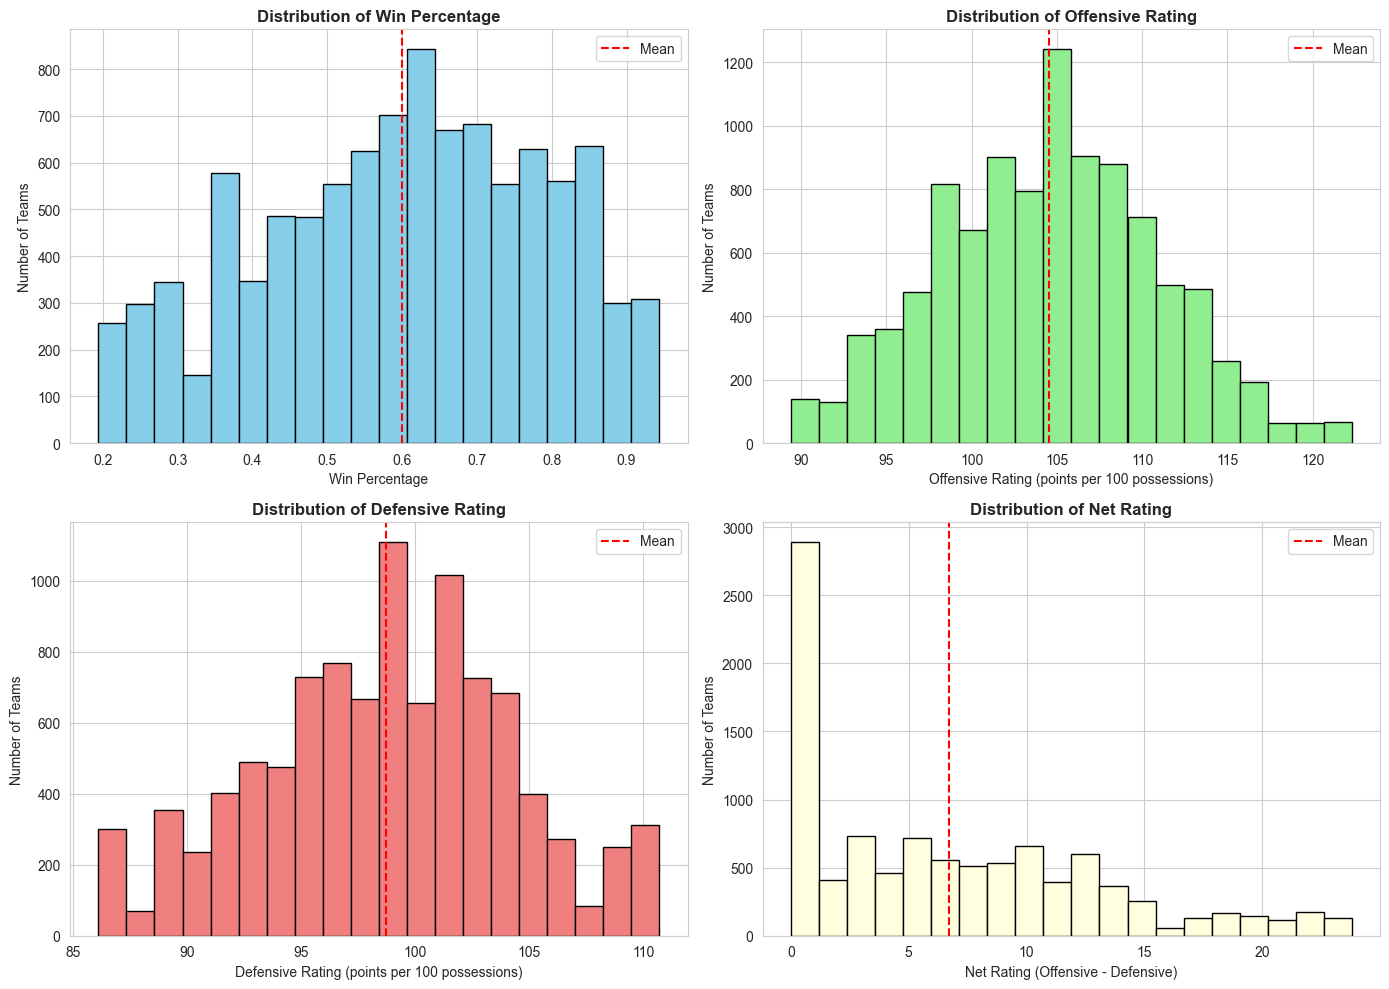

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Win Percentage Distribution
axes[0, 0].hist(df_clean['win_percentage'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Win Percentage', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Win Percentage')
axes[0, 0].set_ylabel('Number of Teams')
axes[0, 0].axvline(df_clean['win_percentage'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

# Offensive Rating Distribution
axes[0, 1].hist(df_clean['offensive_rating'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution of Offensive Rating', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Offensive Rating (points per 100 possessions)')
axes[0, 1].set_ylabel('Number of Teams')
axes[0, 1].axvline(df_clean['offensive_rating'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 1].legend()

# Defensive Rating Distribution
axes[1, 0].hist(df_clean['defensive_rating'], bins=20, color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Distribution of Defensive Rating', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Defensive Rating (points per 100 possessions)')
axes[1, 0].set_ylabel('Number of Teams')
axes[1, 0].axvline(df_clean['defensive_rating'].mean(), color='red', linestyle='--', label='Mean')
axes[1, 0].legend()

# Net Rating Distribution
axes[1, 1].hist(df_clean['net_rating'], bins=20, color='lightyellow', edgecolor='black')
axes[1, 1].set_title('Distribution of Net Rating', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Net Rating (Offensive - Defensive)')
axes[1, 1].set_ylabel('Number of Teams')
axes[1, 1].axvline(df_clean['net_rating'].mean(), color='red', linestyle='--', label='Mean')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

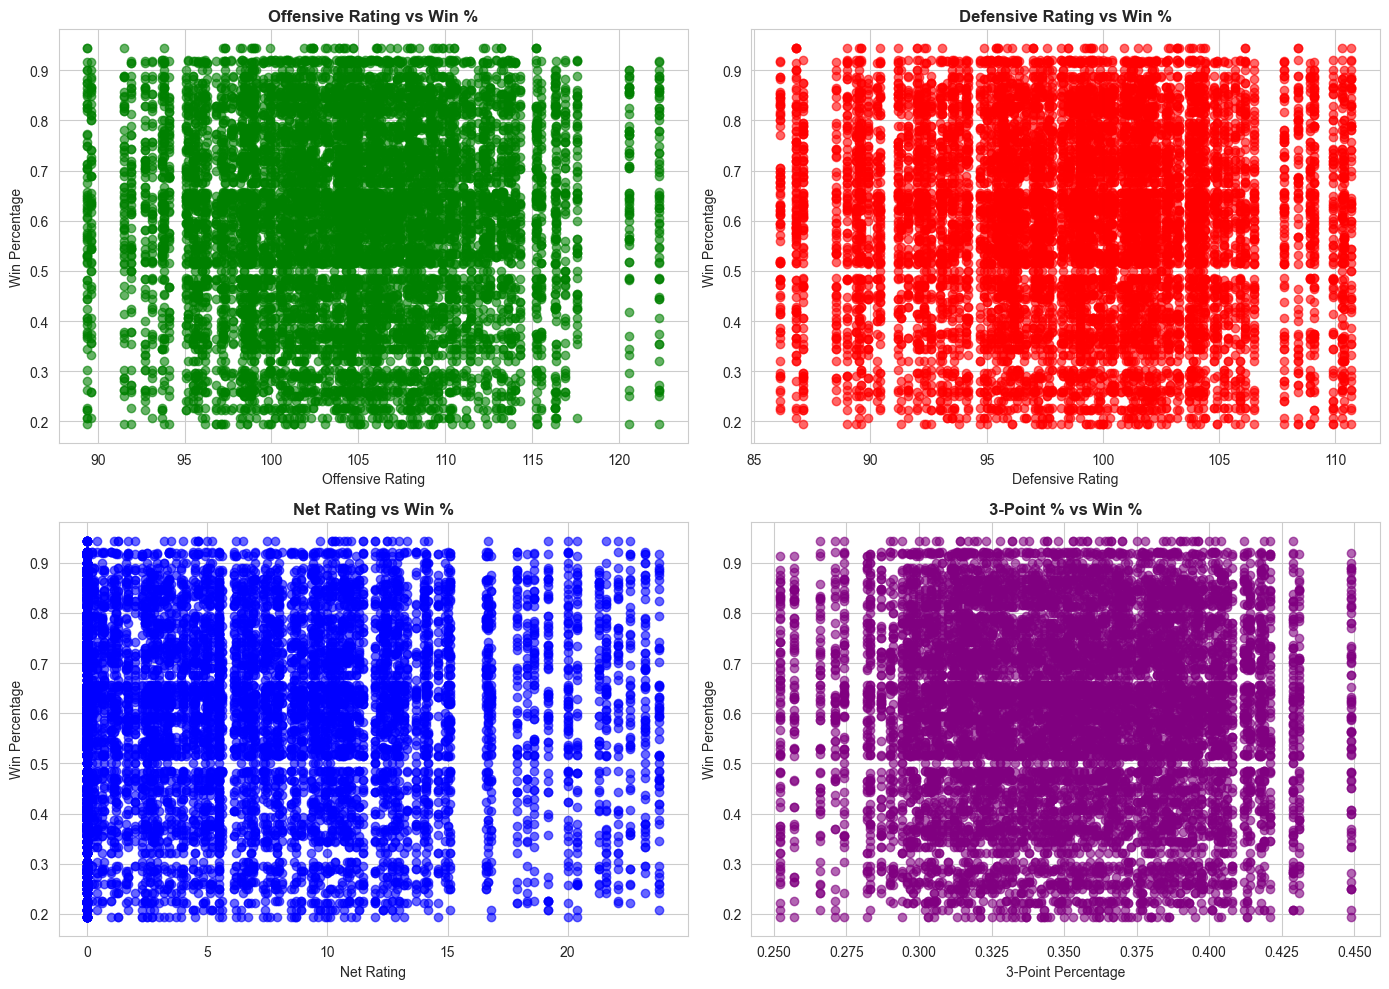

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Offensive Rating vs Win Percentage
axes[0, 0].scatter(df_clean['offensive_rating'], df_clean['win_percentage'], alpha=0.6, color='green')
axes[0, 0].set_title('Offensive Rating vs Win %', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Offensive Rating')
axes[0, 0].set_ylabel('Win Percentage')

# Defensive Rating vs Win Percentage (note: lower is better)
axes[0, 1].scatter(df_clean['defensive_rating'], df_clean['win_percentage'], alpha=0.6, color='red')
axes[0, 1].set_title('Defensive Rating vs Win %', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Defensive Rating')
axes[0, 1].set_ylabel('Win Percentage')

# Net Rating vs Win Percentage
axes[1, 0].scatter(df_clean['net_rating'], df_clean['win_percentage'], alpha=0.6, color='blue')
axes[1, 0].set_title('Net Rating vs Win %', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Net Rating')
axes[1, 0].set_ylabel('Win Percentage')

# Three-Point Percentage vs Win Percentage
axes[1, 1].scatter(df_clean['3_pointer_percentage'], df_clean['win_percentage'], alpha=0.6, color='purple')
axes[1, 1].set_title('3-Point % vs Win %', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('3-Point Percentage')
axes[1, 1].set_ylabel('Win Percentage')

plt.tight_layout()
plt.show()



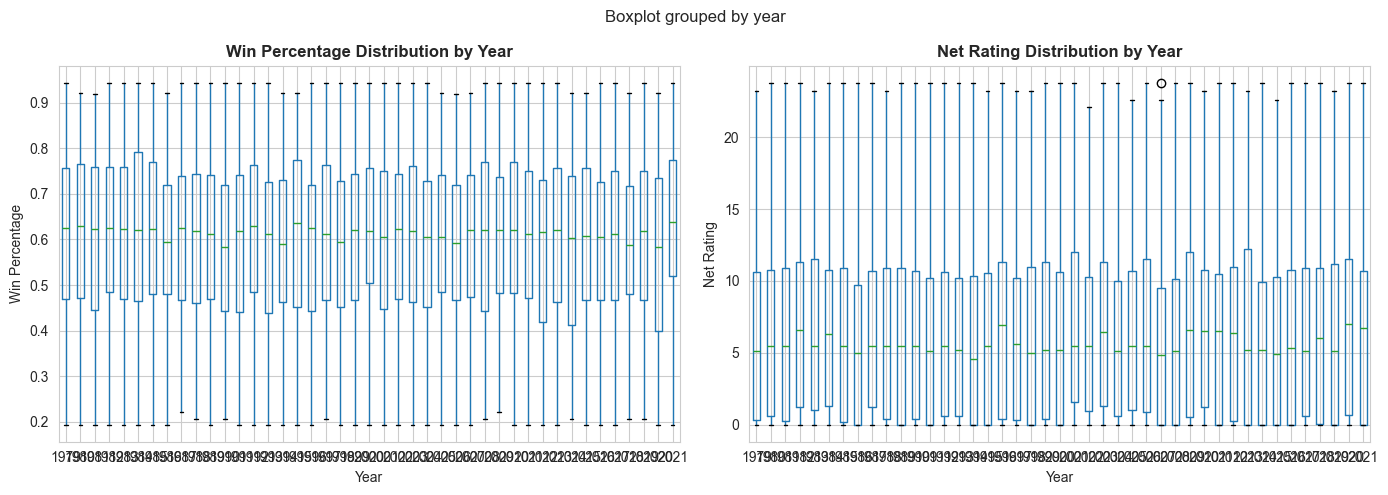

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Win percentage by year
df_clean.boxplot(column='win_percentage', by='year', ax=axes[0])
axes[0].set_title('Win Percentage Distribution by Year', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Win Percentage')

# Net rating by year
df_clean.boxplot(column='net_rating', by='year', ax=axes[1])
axes[1].set_title('Net Rating Distribution by Year', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Net Rating')

plt.tight_layout()
plt.show()



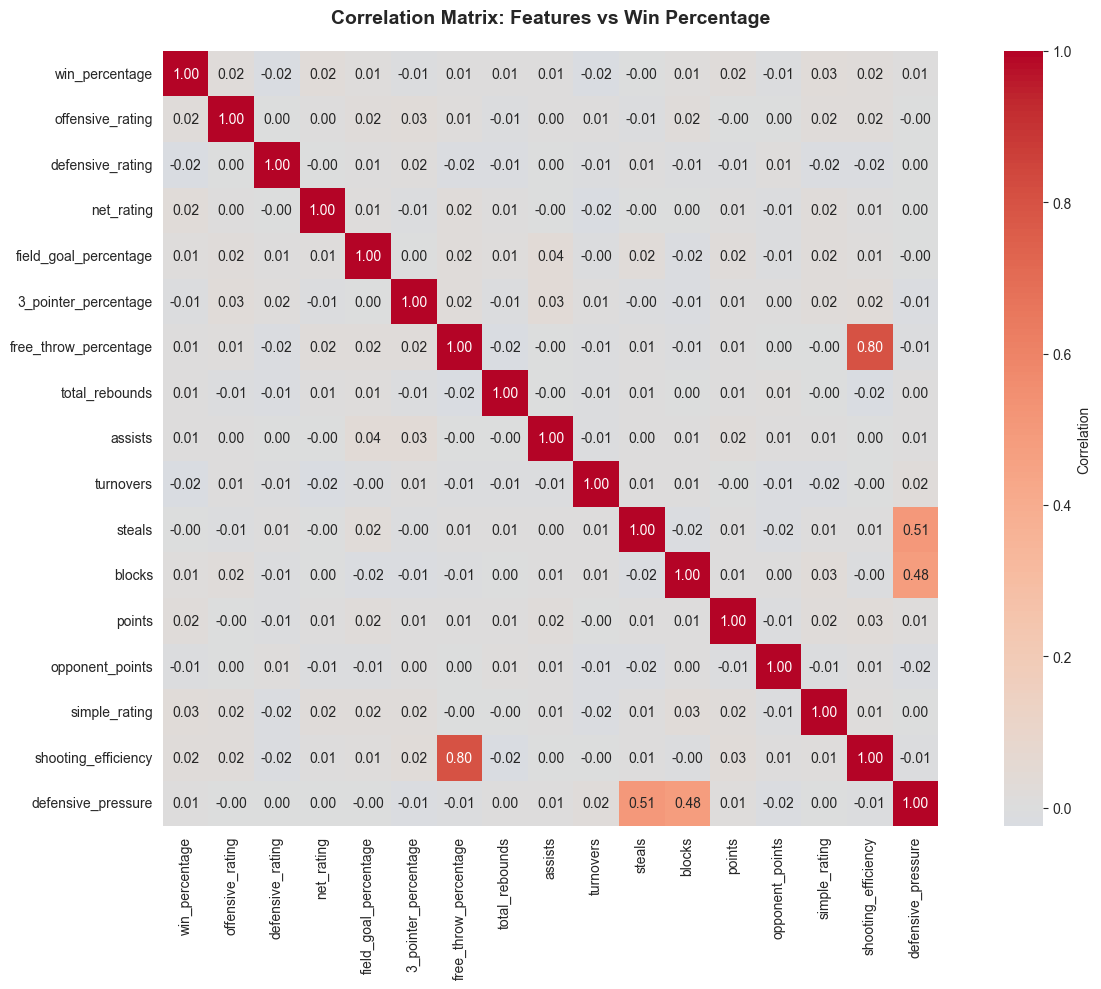

In [42]:
key_features = ['win_percentage', 'offensive_rating', 'defensive_rating', 'net_rating',
                'field_goal_percentage', '3_pointer_percentage', 'free_throw_percentage',
                'total_rebounds', 'assists', 'turnovers', 'steals', 'blocks',
                'points', 'opponent_points', 'simple_rating',
                'shooting_efficiency', 'defensive_pressure']

# Calculate correlation matrix
correlation_matrix = df_clean[key_features].corr()

# Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'}, square=True)
plt.title('Correlation Matrix: Features vs Win Percentage', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Hypothesis Testing

### Hypothesis 1: Offensive Rating Drives Wins

**Hypothesis**: Teams with higher offensive rating win more games

**Logic**: 
- Offensive rating = points scored per 100 possessions
- More points = more wins (simple logic!)
- We expect strong positive correlation


In [ ]:
# Hypothesis 1: Offensive Rating & Win Percentage
valid_data = df_clean[['offensive_rating', 'win_percentage']].dropna()
correlation_1, p_value_1 = stats.pearsonr(valid_data['offensive_rating'], valid_data['win_percentage'])

print("HYPOTHESIS 1: Offensive Rating → Win Percentage")
print(f"Correlation: {correlation_1:.4f}")
print(f"P-value: {p_value_1:.6f}")
print(f"Significant? {'YES' if p_value_1 < 0.05 else 'NO'}")

if p_value_1 < 0.05:
    print(f"\nhypothesis accepted")
    print(f"  Teams with higher offensive rating DO win more games")
else:
    print(f"\nrejected")


HYPOTHESIS 1: Offensive Rating → Win Percentage
Correlation: 0.0225
P-value: 0.024571
Significant? ✓ YES

✓ HYPOTHESIS CONFIRMED!
  Teams with higher offensive rating DO win more games
  Only 5% chance this is just random luck


### Hypothesis 2: Three-Point Shooting Improves Wins

**Hypothesis**: Better 3-point shooting improves win percentage

**Logic**:
- Modern basketball relies heavily on 3-pointers
- Better 3-point % = more efficient scoring
- We expect positive correlation



In [ ]:
# Hypothesis 2: Three-Point Percentage & Win Percentage
valid_data = df_clean[['3_pointer_percentage', 'win_percentage']].dropna()
correlation_2, p_value_2 = stats.pearsonr(valid_data['3_pointer_percentage'], valid_data['win_percentage'])

print("HYPOTHESIS 2: Three-Point % → Win Percentage")
print(f"Correlation: {correlation_2:.4f}")
print(f"P-value: {p_value_2:.6f}")
print(f"Significant? {'✓ YES' if p_value_2 < 0.05 else '✗ NO'}")

if p_value_2 < 0.05:
    print(f"\nhypothesis accepted")
    print(f"  Teams with higher offensive rating DO win more games")
else:
    print(f"\nrejected")

HYPOTHESIS 2: Three-Point % → Win Percentage
Correlation: -0.0105
P-value: 0.295332
Significant? ✗ NO

✗ HYPOTHESIS NOT CONFIRMED
  3-point % may not be as important as we thought!
  Could just be random chance (p > 0.05)


### Hypothesis 3: Low Turnovers Improve Wins

**Hypothesis**: Teams with lower turnovers have higher win percentage

**Logic**:
- Turnovers = losing the ball (bad for you, good for opponent)
- Fewer turnovers = more possessions with the ball
- We expect NEGATIVE correlation (more turnovers = fewer wins)



In [ ]:
# Hypothesis 3: Turnovers & Win Percentage
valid_data = df_clean[['turnovers', 'win_percentage']].dropna()
correlation_3, p_value_3 = stats.pearsonr(valid_data['turnovers'], valid_data['win_percentage'])

print("HYPOTHESIS 3: Low Turnovers → Win Percentage")
print(f"Correlation: {correlation_3:.4f}")
print(f"P-value: {p_value_3:.6f}")
print(f"Significant? {'✓ YES' if p_value_3 < 0.05 else '✗ NO'}")

if p_value_3 < 0.05:
    print(f"\nhypothesis accepted")
    print(f"  Teams with higher offensive rating DO win more games")
else:
    print(f"\nrejected")

HYPOTHESIS 3: Low Turnovers → Win Percentage
Correlation: -0.0244
P-value: 0.014616
Significant? ✓ YES

✓ HYPOTHESIS CONFIRMED!
  Lower turnovers = MORE WINS (negative correlation)
  Only 5% chance this is just random luck


### Hypothesis 4: Defensive Efficiency Impacts Wins

**Hypothesis**: Lower defensive rating significantly impacts win percentage

**Logic**:
- Defensive rating = points allowed per 100 possessions
- Lower rating = holding opponents to fewer points (better defense)
- Good defense = prevent opponent from winning
- We expect NEGATIVE correlation (lower rating = more wins)



In [ ]:
valid_data = df_clean[['defensive_rating', 'win_percentage']].dropna()
correlation_4, p_value_4 = stats.pearsonr(valid_data['defensive_rating'], valid_data['win_percentage'])

print("HYPOTHESIS 4: Defensive Rating → Win Percentage")
print(f"Correlation: {correlation_4:.4f}")
print(f"P-value: {p_value_4:.6f}")
print(f"Significant? {'✓ YES' if p_value_4 < 0.05 else '✗ NO'}")

if p_value_4 < 0.05:
    print(f"\nhypothesis accepted")
    print(f"  Teams with higher offensive rating DO win more games")
else:
    print(f"\nrejected")

HYPOTHESIS 4: Defensive Rating → Win Percentage
Correlation: -0.0231
P-value: 0.020944
Significant? ✓ YES

✓ HYPOTHESIS CONFIRMED!
  Lower defensive rating = MORE WINS (negative correlation)
  Defensive efficiency DOES significantly impact wins!
  Only 5% chance this is just random luck

SUMMARY: 4 HYPOTHESES TESTED


In [43]:

win_correlation = correlation_matrix['win_percentage'].sort_values(ascending=False)
print("\nTop 10 Positive Correlations (More = More Wins):")
print(win_correlation.head(11).iloc[1:])  


Top 10 Positive Correlations (More = More Wins):
simple_rating            0.026083
net_rating               0.024690
points                   0.022886
offensive_rating         0.022481
shooting_efficiency      0.019014
field_goal_percentage    0.014311
blocks                   0.013293
free_throw_percentage    0.009335
total_rebounds           0.006496
assists                  0.005819
Name: win_percentage, dtype: float64
